In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  USER CONFIG
# ══════════════════════════════════════════════════════════════════════════════

DIRECTION   = (1, 1, 1)    # muon direction
MOMENTUM    = 1000.0       # kinetic energy in MeV

VOL = 1                    # which detector volume
N_WIRES_CONTEXT = 1        # extra wires to plot either side of peak wire

In [2]:
import sys
sys.path.append('../')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from tools.geometry import generate_detector
from tools.simulation import DetectorSimulator
from tools.loader import build_deposit_data
from tools.particle_generator import generate_muon_track
from tools.visualization import _extract_viz_params

cfg = generate_detector('../config/cubic_wireplane_config.yaml')

_common = dict(
    differentiable=True,
    n_segments=50_000,
    use_bucketed=True,
    max_active_buckets=1000,
    include_noise=False,
    include_electronics=True,
    include_track_hits=False,
    track_config=None,
)

simulator       = DetectorSimulator(cfg, include_digitize=True,  **_common)
simulator_nodigi = DetectorSimulator(cfg, include_digitize=False, **_common)

simulator.warm_up()
simulator_nodigi.warm_up()
sim_cfg = simulator.config

--- Creating DetectorSimulator ---
   Extracting parameters...


E0422 12:57:33.598140   43197 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0422 12:57:33.613058   43120 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=50,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
--- Creating DetectorSimulator ---
   Extracting parameters...
   Loading response kernels...
   Space charge effects: DISABLED
   Recombination model: emb
   Config: total_pad=50,000, response_chunk=50,000, num_s=16, K_wire=2, K_time=6
   Track labeling: DISABLED
   Readout: wire
   Volumes: 2 (iterate=scan)
--- DetectorSimulator Ready ---
Triggering JIT compilation...
JIT compilation finished (total_pad=50,000, iterate=scan).
Triggering JIT compilation...
JIT compilation finished (total_pad=50,000, iterate=scan).


In [3]:
track = generate_muon_track(
    start_position_mm=(0.0, 0.0, 0.0),
    direction=DIRECTION,
    kinetic_energy_mev=MOMENTUM,
    step_size_mm=0.1,
    track_id=1,
    #detector_bounds_mm=((-300, 300), (-300, 300), (-300, 300)),
)
deposits = build_deposit_data(
    track['position'], track['de'], track['dx'], sim_cfg,
    theta=track['theta'], phi=track['phi'],
    track_ids=track['track_id'],
)
print(f'Generated {len(track["de"]):,} deposits')

Generated 44,083 deposits


In [4]:
params     = simulator.default_sim_params
plane_keys = [(v, p) for v in range(sim_cfg.n_volumes) for p in range(sim_cfg.volumes[VOL].n_planes)]

out_tuple       = simulator.forward(params, deposits)
out_tuple_nodigi = simulator_nodigi.forward(params, deposits)
jax.block_until_ready(out_tuple)
jax.block_until_ready(out_tuple_nodigi)

arrays       = {k: np.asarray(a) for k, a in zip(plane_keys, out_tuple)}
arrays_nodigi = {k: np.asarray(a) for k, a in zip(plane_keys, out_tuple_nodigi)}

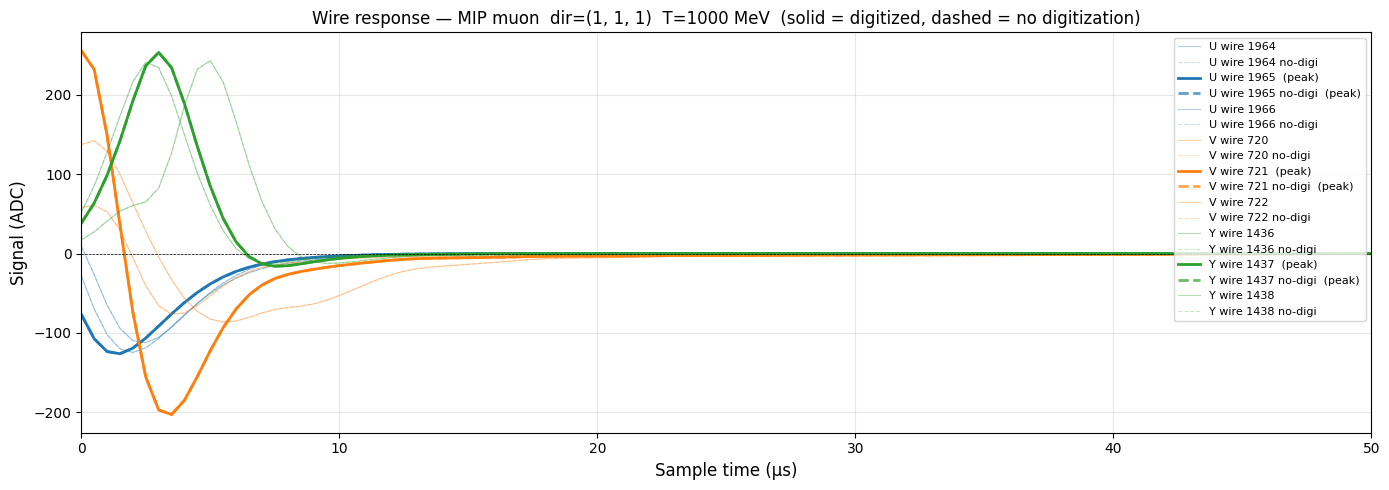

In [5]:
vp        = _extract_viz_params(sim_cfg)
time_step = vp['time_step_us']
n_ticks   = arrays[(VOL, 0)].shape[1]
t_axis    = np.arange(n_ticks) * time_step  # μs
e_per_adc = sim_cfg.electrons_per_adc

PLANE_LETTERS = {0: 'U', 1: 'V', 2: 'Y'}
PLANE_COLORS  = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c'}

n_planes = sim_cfg.volumes[VOL].n_planes
fig, ax  = plt.subplots(figsize=(14, 5), facecolor='white')

for p in range(n_planes):
    arr       = arrays[(VOL, p)]
    peak_wire = int(np.argmax(np.abs(arr).max(axis=1)))

    w_lo = max(0, peak_wire - N_WIRES_CONTEXT)
    w_hi = min(arr.shape[0], peak_wire + N_WIRES_CONTEXT + 1)

    for w in range(w_lo, w_hi):
        is_peak = (w == peak_wire)
        lw      = 2.0 if is_peak else 0.8
        alpha   = 1.0 if is_peak else 0.35
        color   = PLANE_COLORS[p]

        label_digi  = f'{PLANE_LETTERS[p]} wire {w}{"  (peak)" if is_peak else ""}'
        label_nodigi = f'{PLANE_LETTERS[p]} wire {w} no-digi{"  (peak)" if is_peak else ""}'

        ax.plot(t_axis, arr[w],
                color=color, lw=lw, alpha=alpha, label=label_digi)
        ax.plot(t_axis, arrays_nodigi[(VOL, p)][w],
                color=color, lw=lw, alpha=alpha * 0.7,
                ls='--', label=label_nodigi)

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('Sample time (μs)', fontsize=12)
ax.set_ylabel('Signal (ADC)', fontsize=12)
ax.set_title(
    f'Wire response — MIP muon  dir={DIRECTION}  T={MOMENTUM:.0f} MeV  '
    f'(solid = digitized, dashed = no digitization)',
    fontsize=12,
)
ax.set_xlim([0, 50])
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()